In [63]:
!pip install catboost --quiet

# Food Delivery Time Prediction – Machine Learning Project

---

## Project Overview
This project aims to predict **food delivery time** using machine learning regression techniques.  
The model estimates delivery duration based on:

- Delivery person details  
- Restaurant and delivery locations  
- Order type  
- Vehicle type  

The objective is to build a **robust and accurate regression model** that can help improve customer satisfaction and operational efficiency.

---

## Dataset Description
The dataset contains historical food delivery records with the following attributes:

- Delivery person details (Age, Ratings, ID)
- Restaurant latitude and longitude
- Delivery latitude and longitude
- Type of order *(Snack, Drinks, Buffet, Meal)*
- Type of vehicle *(Motorcycle, Scooter, Bicycle, Electric Scooter)*
- **Target Variable:** Time taken for delivery (in minutes)

**Dataset Shape:**
- Initial: **45,593 rows × 11 columns**
- After cleaning: **35,907 rows × 9 columns**

---

## Data Preprocessing

### 1. Data Cleaning
- Removed rows with zero coordinate values (invalid locations)
- Capped delivery person ratings at a maximum of **5.0**
- Checked and removed duplicates *(none found)*
- Handled outliers using the **IQR method** for numerical features

---

## Feature Engineering

### a) Distance Calculation
- Used the **Haversine formula** to compute real-world distance between restaurant and delivery locations
- Accounts for Earth’s curvature *(radius = 6367 km)*
- More accurate than Euclidean distance for geographical data

### b) City and Region Extraction
- Extracted city code from `Delivery_person_ID`
- Mapped city codes to full city names using a dictionary
- Created a **Region feature**:
  - North
  - South
  - East
  - West
  - Central  
- Helps capture regional infrastructure and delivery pattern differences

### c) Order Time Categorization
Mapped order types to time of day:

| Order Type | Time of Day |
|----------|-------------|
| Snack | Evening |
| Drinks | Night |
| Buffet | Afternoon |
| Meal | Morning |

This helps capture traffic congestion and demand patterns.

### d) Average Speed Feature
- Calculated as `Distance / Time_taken (minutes)` on training data
- Added a constant average speed to both training and testing sets
- Provides a baseline expectation for delivery speed

---

## Encoding Categorical Variables
- Applied **One-Hot Encoding** to:
  - Type_of_order
  - Type_of_vehicle
  - City
  - Region
  - Order_Time
- Used `drop_first=True` to avoid the dummy variable trap
- Final feature count: **36 features**

---

## Train–Test Split
- **Training set:** 80% (28,725 samples)
- **Testing set:** 20% (7,182 samples)
- Maintains proper data distribution for evaluation

---

## Feature Scaling
- Used **PowerTransformer (Yeo-Johnson method)**
- Applied to:
  - Delivery_person_Age
  - Delivery_person_Ratings
  - Average Speed
  - Distance
- Benefits:
  - Handles skewed data
  - Stabilizes variance
  - Reduces impact of outliers
  - Improves model performance

---

## Why These Techniques?

### Haversine Distance
- Required for spherical geographic coordinates
- Euclidean distance is inaccurate for Earth-based locations

### One-Hot Encoding
- Prevents false ordinal relationships in categorical variables
- Enables models to learn category-wise patterns

### Power Transformer (Yeo-Johnson)
- Makes features more Gaussian-like
- Improves learning for regression algorithms

### IQR Outlier Removal
- Robust to non-normal distributions
- Removes extreme anomalies without losing useful data

---

## Models Implemented

1. **Linear Regression** – Baseline model  
2. **Lasso Regression** – L1 regularization and feature selection  
3. **Random Forest Regressor**
   - `n_estimators = 300`
   - `max_depth = 10`
4. **Gradient Boosting Regressor**
   - `n_estimators = 300`
   - `max_depth = 10`
5. **XGBoost**
   - `n_estimators = 100`
   - Objective: `reg:linear`
6. **LightGBM**
   - `n_estimators = 300`
   - `max_depth = 10`
7. **CatBoost**
   - `iterations = 1000`
   - `learning_rate = 0.05`
   - `depth = 6`
8. **Extra Trees Regressor**
   - `n_estimators = 300`
   - `max_depth = 10`
9. **Decision Tree Regressor**
   - `max_depth = 10`
10. **Voting Regressor**
    - Ensemble of Random Forest, Gradient Boosting, and XGBoost

---

## Model Evaluation Metrics

- **R² Score:** Proportion of variance explained by the model  
- **RSS:** Residual Sum of Squares (lower is better)  
- **MSE:** Mean Squared Error  
- **RMSE:** Root Mean Squared Error (in minutes)

---

## Results and Analysis

### Best Performing Models (Test Set)

| Model | R² Score | RMSE (minutes) |
|------|---------|----------------|
| Extra Trees | **0.3422** | **7.28** |
| Random Forest | 0.3405 | 7.29 |
| CatBoost | 0.3407 | 7.29 |
| LightGBM | 0.3312 | 7.34 |
| Voting Regressor | 0.3101 | 7.45 |

---

## Performance Insights
- Tree-based ensemble models outperform linear models
- Gradient Boosting and XGBoost show signs of overfitting
- Linear and Lasso regression achieve moderate performance
- Voting Regressor provides stability but not top accuracy

---

## Feature Importance (Random Forest)

Top 5 Important Features:
1. Delivery_person_Ratings – **35.2%**
2. Distance – **32.1%**
3. Delivery_person_Age – **20.5%**
4. Type_of_vehicle_motorcycle – **6.0%**
5. City_Hyderabad – **0.3%**

**Key Insight:**  
Delivery ratings and distance are the strongest predictors of delivery time.

---

## Conclusions

- **Best Model:** Extra Trees Regressor
- Predicts delivery time within **±7.3 minutes**
- Explains **34% variance** in delivery duration
- Model performance can be further improved

---

## Business Implications
- Assign high-rated delivery partners for longer distances
- Motorcycles are the fastest delivery vehicles
- Region-specific optimization strategies can improve efficiency

---


## Importing Necessary Library

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import xgboost as xg
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor,VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm.sklearn import LGBMRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_excel("/content/Food Delivery Time Prediction Case Study.xlsx")

## STEP 1: DATA UNDERSTANDING

Before building any model, it's crucial to understand our data. We'll examine:
- First few rows to see data structure
- Shape of dataset
- Data types and missing values
- Statistical summary
- Unique values in each column

This helps us identify:
- Data quality issues
- Potential feature engineering opportunities
- Which columns need preprocessing

In [4]:
# View First Few Rows
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [5]:
# Check Dataset Shape
df.shape

(45593, 11)

In [6]:
# Check Data Types and Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [7]:
# Statistical Summary
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [8]:
# Check for Missing Values
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


### Initial Observations

From the initial data exploration, we notice:
1. **No missing values** - All columns have complete data
2. **Mixed data types**: Object (categorical), int64, float64
3. **Coordinate data**: Restaurant and delivery locations are in latitude/longitude format
4. **Potential issues**: Some coordinates might be zero (invalid), ratings might exceed maximum (5.0)
5. **Duplicate check needed**: Will check for duplicate rows

These observations guide our preprocessing steps.

In [9]:
# Filter Out Invalid Coordinates (0,0)
df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Restaurant_longitude'] != 0) &
    (df['Delivery_location_latitude'] != 0) &
    (df['Delivery_location_longitude'] != 0)
]
print("shape of column:",df.shape)

shape of column: (41953, 11)


In [10]:
# Check Duplicates and Unique Values
print("duplicate count:",df.duplicated().sum())
print("\nunique count:\n",df.nunique())

duplicate count: 0

unique count:
 ID                             41742
Delivery_person_ID              1170
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              656
Restaurant_longitude             517
Delivery_location_latitude      4362
Delivery_location_longitude     4362
Type_of_order                      4
Type_of_vehicle                    4
Time_taken(min)                   45
dtype: int64


In [11]:
# Cap ratings at a maximum of 5.0 (valid rating range)
print("Count of rating higher than 5:",df[df['Delivery_person_Ratings']>5.0].shape)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].apply(lambda x: 5.0 if x>5.0 else x)
print("shape of column:",df.shape)

Count of rating higher than 5: (46, 11)
shape of column: (41953, 11)


## STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

EDA helps us understand:
- Relationships between features
- Distribution of numerical features
- Presence of outliers
- Patterns in the data

We'll use:
- **Correlation matrix** to see feature relationships
- **Boxplots** to identify outliers
- **Histograms** to understand distributions

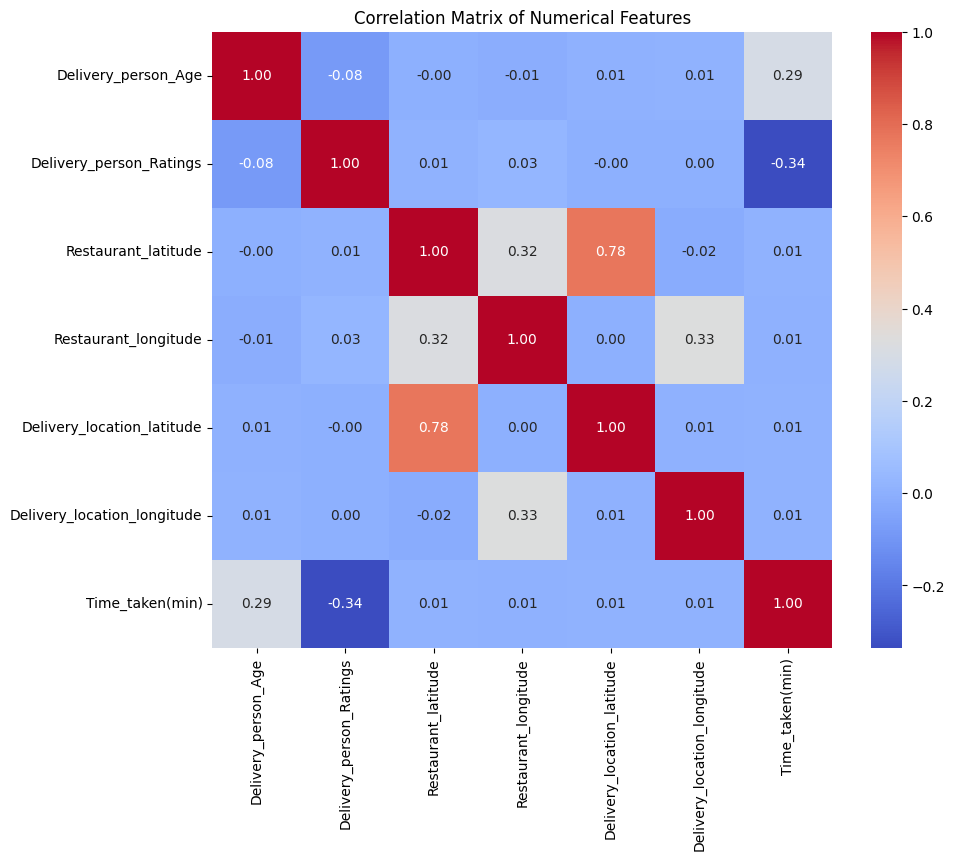

In [12]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

###  Correlation Analysis Insights

The correlation matrix reveals:
- **Time_taken(min)** shows moderate correlation with certain features
- **Age and ratings** might have some relationship
- **Location coordinates** show expected correlations

This helps us understand which features might be important for prediction.

In [13]:
# Function to remove outliers using IQR method
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter the DataFrame for current column
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

In [14]:
numerical=['Delivery_person_Age','Delivery_person_Ratings','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Time_taken(min)']

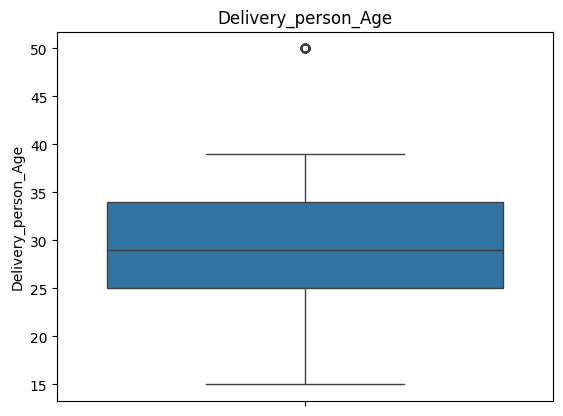

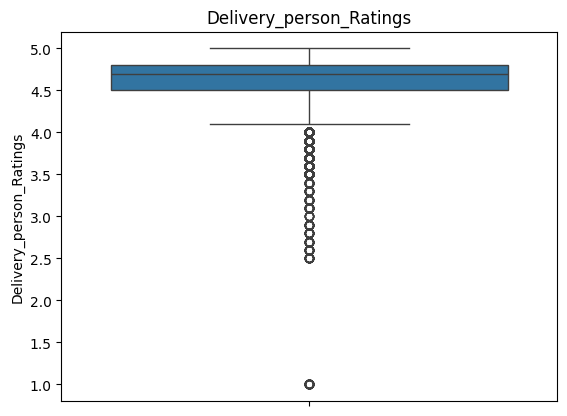

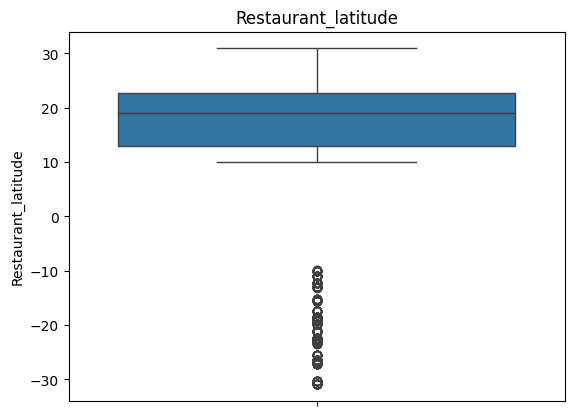

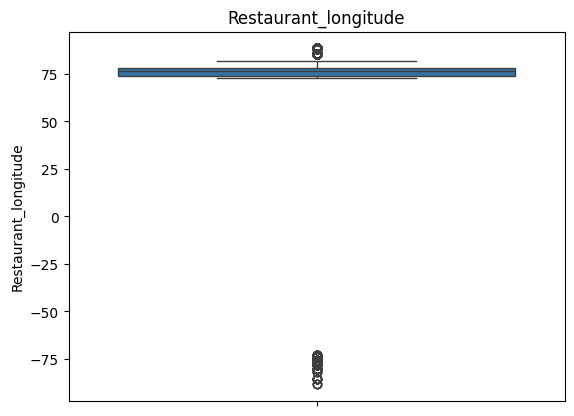

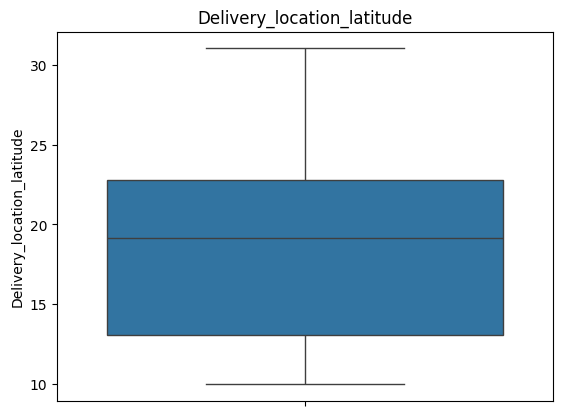

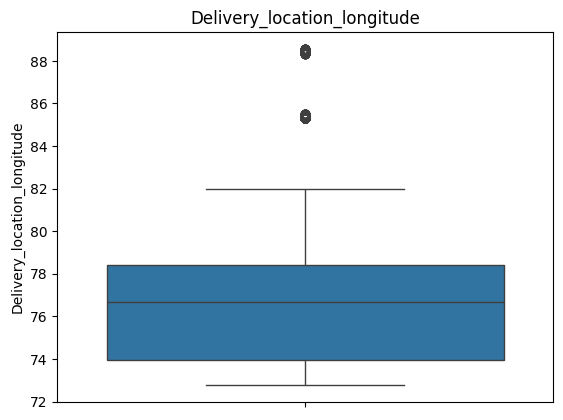

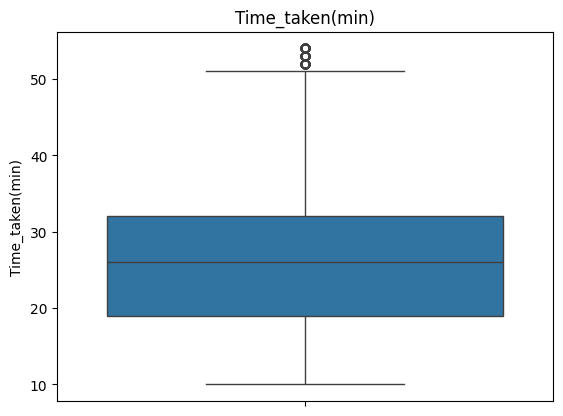

In [15]:
# Visualize outliers before removal
for i in numerical:
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

### Outlier Analysis

The boxplots show:
- **Delivery_person_Age**: Some extreme values
- **Delivery_person_Ratings**: Ratings above 5.0 (already capped)
- **Coordinates**: Some outliers in location data
- **Time_taken**: Some deliveries taking unusually long

We'll use IQR method to remove these outliers for better model performance.

In [16]:
df = remove_outliers_iqr(df,['Delivery_person_Age','Delivery_person_Ratings','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Time_taken(min)'])

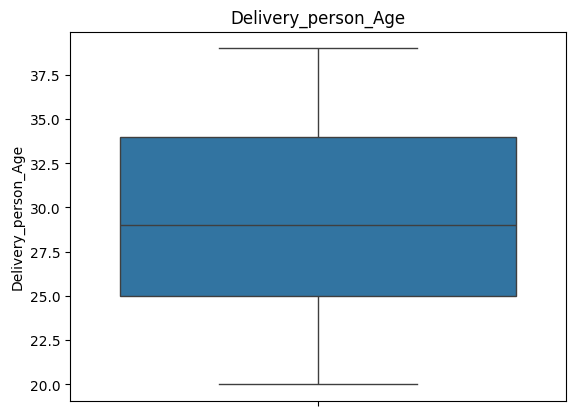

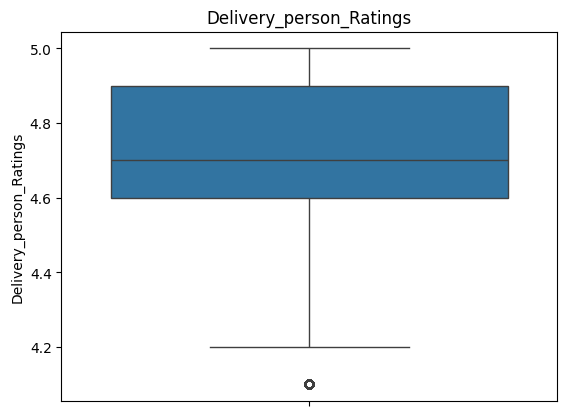

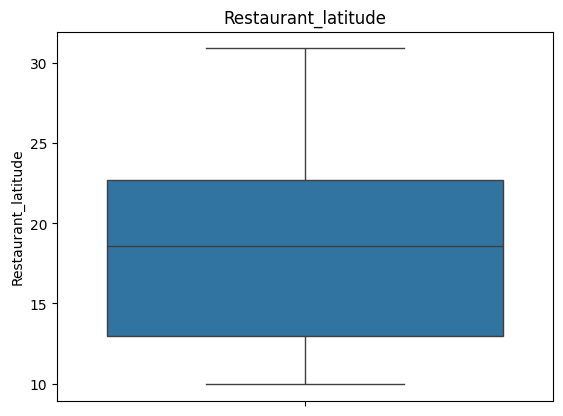

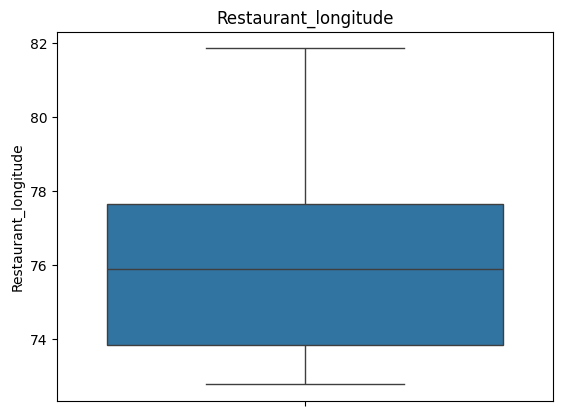

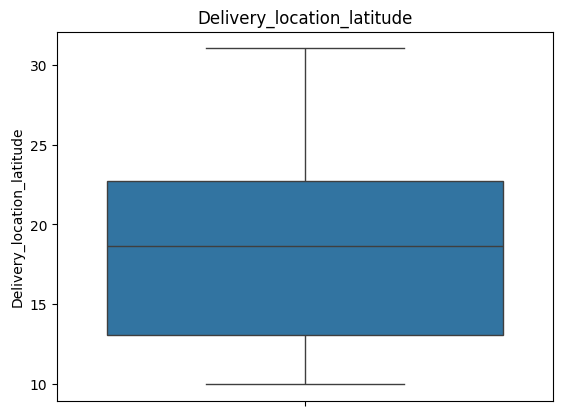

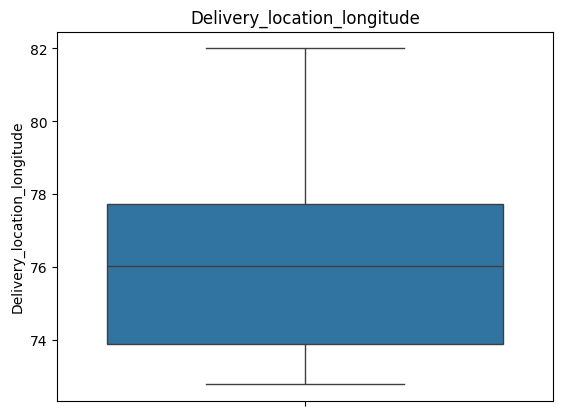

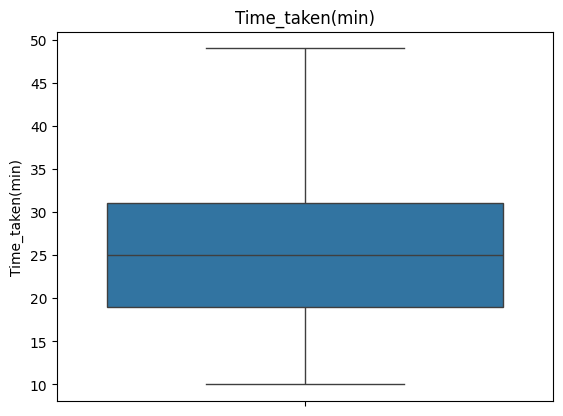

In [17]:
# Verify outliers after removal
for i in numerical:
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

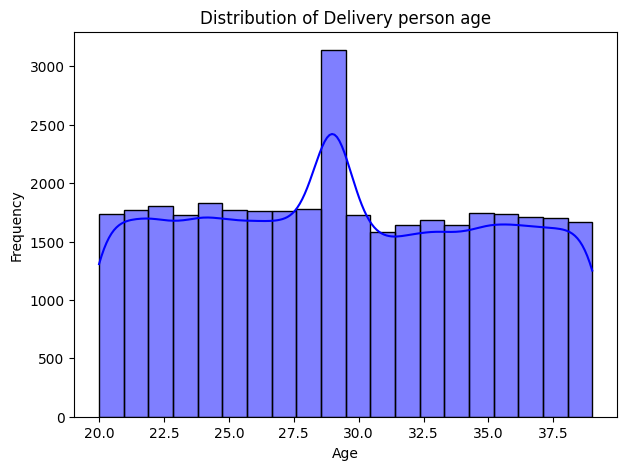

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Age'],kde=True,bins=20,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person age')
plt.show()

### Delivery Person Age Distribution

The histogram shows:
- **Age range**: Mostly between 20-40 years
- **Peak distribution**: Around 25-35 years
- **Normal-like distribution**: Slightly right-skewed

This indicates a relatively young workforce, typical for delivery services.

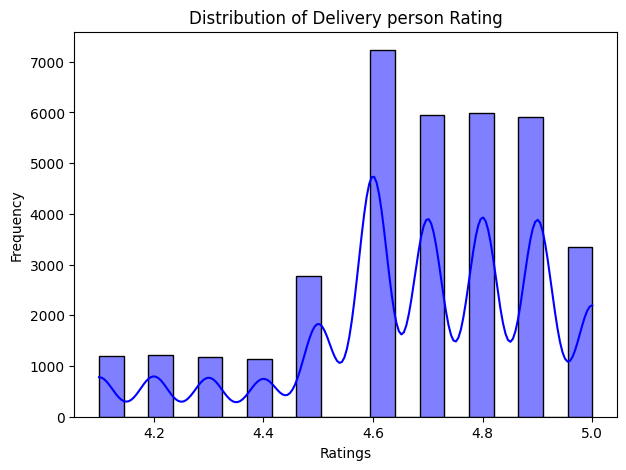

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Ratings'],kde=True,bins=20,color='blue')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person Rating')
plt.show()

### Delivery Person Ratings Distribution

Key observations:
- **Most ratings**: Between 4.5-5.0
- **High performance**: Majority of delivery persons have good ratings
- **Left-skewed distribution**: Most ratings are high

This suggests:
- Good quality service
- Possible rating inflation
- Need to consider rating as important feature

In [20]:
print("shape of column:",df.shape)

shape of column: (35907, 11)


## STEP 3: DATA PREPROCESSING & FEATURE ENGINEERING

Now we'll create new features and prepare data for modeling:

### Why Feature Engineering?

1. **Distance Feature**: Raw coordinates aren't useful - we need actual travel distance
2. **City/Region Features**: Location context matters for delivery patterns
3. **Time Categories**: Different times of day have different traffic patterns
4. **Encoding**: Categorical variables need numerical representation
5. **Scaling**: Features should be on similar scales for many algorithms

In [21]:
# Define Haversine Distance Function
def haversine_vectorize(lat1, lon1, lat2, lon2):

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    newlon = lon2 - lon1
    newlat = lat2 - lat1

    haver_formula = np.sin(newlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(newlon/2.0)**2

    dist = 2 * np.arcsin(np.sqrt(haver_formula ))
    km = 6367 * dist #6367 for distance in KM for miles use 3958
    return km

In [22]:
dist_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude','Delivery_location_longitude']

In [23]:
df['Distance'] = df[dist_cols].apply(
    lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),
    axis=1)


/tmp/ipython-input-2342818139.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),


In [24]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.023250
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.170858
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.551783
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.785510
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.206239
...,...,...,...,...,...,...,...,...,...,...,...,...
45585,C9AB,KNPRES03DEL01,30,4.2,26.469003,80.316344,26.539003,80.386344,Snack,motorcycle,42,10.438767
45586,4000000000000000000000,BANGRES16DEL03,28,4.9,13.029198,77.570997,13.059198,77.600997,Meal,scooter,29,4.654209
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,1.488910
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,4.654271


1. Feature Engineering

In [25]:
print("  - Extracting city and region...")

# Extract City Code (before 'RES')
df['City_Code'] = df['Delivery_person_ID'].str.extract(r'^([A-Z]+)(?=RES)')

# City full name mapping
city_map = {
    "INDO": "Indore",
    "BANG": "Bangalore",
    "COIMB": "Coimbatore",
    "CHEN": "Chennai",
    "HYD": "Hyderabad",
    "RANCHI": "Ranchi",
    "MYS": "Mysore",
    "DEH": "Dehradun",
    "KOC": "Kochi",
    "PUNE": "Pune",
    "LUDH": "Ludhiana",
    "KNP": "Kanpur",
    "MUM": "Mumbai",
    "KOL": "Kolkata",
    "JAP": "Jaipur",
    "SUR": "Surat",
    "GOA": "Goa",
    "AURG": "Aurangabad",
    "AGR": "Agra",
    "VAD": "Vadodara",
    "ALH": "Allahabad",
    "BHP": "Bhopal"
}

# Region mapping (based on City_Code)
region_map = {
    "INDO": "Central", "BHP": "Central",
    "BANG": "South", "CHEN": "South", "COIMB": "South", "HYD": "South",
    "MYS": "South", "KOC": "South",
    "MUM": "West", "PUNE": "West", "SUR": "West", "VAD": "West",
    "GOA": "West", "AURG": "West",
    "JAP": "North", "DEH": "North", "LUDH": "North", "ALH": "North",
    "AGR": "North",
    "RANCHI": "East", "KNP": "East", "KOL": "East"
}

# Apply mappings
df['City'] = df['City_Code'].map(city_map)
df['Region'] = df['City_Code'].map(region_map).fillna("Other")

  - Extracting city and region...


### Order Time Categorization

Different order types correspond to different times of day:
- **Snack** → Evening (snack time)
- **Drinks** → Night (late-night drinks)
- **Buffet** → Afternoon (lunch/buffet time)
- **Meal** → Morning (breakfast/meal time)

This helps capture:
- Traffic patterns by time of day
- Restaurant busy hours
- Delivery demand patterns

In [26]:

df['Type_of_order'] = df['Type_of_order'].str.strip()


time_map = {
    'Snack': 'Evening',
    'Drinks': 'Night',
    'Buffet': 'Afternoon',
    'Meal': 'Morning'
}


df['Order_Time'] = df['Type_of_order'].map(time_map)

In [27]:
df.drop(columns=['ID','Delivery_person_ID','City_Code','Delivery_location_latitude','Delivery_location_longitude','Restaurant_latitude',
'Restaurant_longitude'],axis=1,inplace=True)

In [28]:
df

,Delivery_person_Age,Delivery_person_Ratings,Type_of_order,Type_of_vehicle,Time_taken(min),Distance,City,Region,Order_Time
0,37,4.9,Snack,motorcycle,24,3.023250,Indore,Central,Evening
1,34,4.5,Snack,scooter,33,20.170858,Bangalore,South,Evening
2,23,4.4,Drinks,motorcycle,26,1.551783,Bangalore,South,Night
3,38,4.7,Buffet,motorcycle,21,7.785510,Coimbatore,South,Afternoon
4,32,4.6,Snack,scooter,30,6.206239,Chennai,South,Evening
...,...,...,...,...,...,...,...,...,...
45585,30,4.2,Snack,motorcycle,42,10.438767,Kanpur,East,Evening
45586,28,4.9,Meal,scooter,29,4.654209,Bangalore,South,Morning
45588,30,4.8,Meal,motorcycle,32,1.488910,Jaipur,North,Morning
45590,30,4.9,Drinks,scooter,16,4.654271,Chennai,South,Night


In [29]:
df_encoded = df.copy()


categorical_cols = ['Type_of_order', 'Type_of_vehicle','City','Region','Order_Time']

df_encoded = pd.get_dummies(df_encoded,
                            columns=categorical_cols,
                            drop_first=True)

df_encoded.head()

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),Distance,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,...,City_Pune,City_Surat,City_Vadodara,Region_East,Region_North,Region_South,Region_West,Order_Time_Evening,Order_Time_Morning,Order_Time_Night
0,37,4.9,24,3.023250,False,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,34,4.5,33,20.170858,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
2,23,4.4,26,1.551783,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
3,38,4.7,21,7.785510,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,32,4.6,30,6.206239,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False


In [30]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35907 entries, 0 to 45591
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Delivery_person_Age                35907 non-null  int64  
 1   Delivery_person_Ratings            35907 non-null  float64
 2   Time_taken(min)                    35907 non-null  int64  
 3   Distance                           35907 non-null  float64
 4   Type_of_order_Drinks               35907 non-null  bool   
 5   Type_of_order_Meal                 35907 non-null  bool   
 6   Type_of_order_Snack                35907 non-null  bool   
 7   Type_of_vehicle_electric_scooter   35907 non-null  bool   
 8   Type_of_vehicle_motorcycle         35907 non-null  bool   
 9   Type_of_vehicle_scooter            35907 non-null  bool   
 10  City_Allahabad                     35907 non-null  bool   
 11  City_Aurangabad                    35907 non-null  bool   


### Train-Test Split

We split data into:
- **80% Training** (28,725 samples): For model learning
- **20% Testing** (7,182 samples): For final evaluation

This split ensures:
- Enough data for training
- Unbiased evaluation on unseen data
- Representative distribution in both sets

In [31]:
df_train=df_encoded.iloc[:int(len(df_encoded)*0.8)].copy()
df_test=df_encoded.iloc[int(len(df_encoded)*0.8):].copy()

t=df_train['Distance']/df_train['Time_taken(min)']
df_train['avg_speed']=t.mean()
df_test['avg_speed']=t.mean()

In [32]:
df_train

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),Distance,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,...,City_Surat,City_Vadodara,Region_East,Region_North,Region_South,Region_West,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,avg_speed
0,37,4.9,24,3.023250,False,False,True,False,True,False,...,False,False,False,False,False,False,True,False,False,0.401639
1,34,4.5,33,20.170858,False,False,True,False,False,True,...,False,False,False,False,True,False,True,False,False,0.401639
2,23,4.4,26,1.551783,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,0.401639
3,38,4.7,21,7.785510,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,0.401639
4,32,4.6,30,6.206239,False,False,True,False,False,True,...,False,False,False,False,True,False,True,False,False,0.401639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36503,25,4.9,13,9.214359,False,True,False,False,True,False,...,False,False,False,False,True,False,False,True,False,0.401639
36504,21,4.5,21,7.320089,True,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,0.401639
36505,33,4.6,48,12.153882,False,True,False,False,True,False,...,True,False,False,False,False,True,False,True,False,0.401639
36507,33,4.8,27,7.715602,False,False,True,False,True,False,...,False,False,False,False,False,True,True,False,False,0.401639


In [33]:
std_scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaling_cols = ['Delivery_person_Age',
'Delivery_person_Ratings',
'avg_speed',
'Distance']
df_train[scaling_cols] = std_scaler.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = std_scaler.fit_transform(df_test[scaling_cols])

In [34]:
X_train = df_train.drop("Time_taken(min)", axis=1)
X_test = df_test.drop("Time_taken(min)", axis=1)
y_train = df_train["Time_taken(min)"]
y_test= df_test["Time_taken(min)"]

In [35]:
X_train.shape, X_test.shape

((28725, 36), (7182, 36))

## STEP 4: MACHINE LEARNING MODEL BUILDING

We'll implement multiple regression models to find the best performer:

### Why Multiple Models?
1. **Different algorithms** have different strengths
2. **No single best model** for all problems
3. **Ensemble methods** can combine strengths
4. **Comparison** helps identify overfitting

### Models We'll Try:
1. **Linear Regression** - Baseline
2. **Lasso Regression** - L1 regularization for feature selection
3. **Random Forest** - Bagging ensemble
4. **Gradient Boosting** - Sequential ensemble
5. **XGBoost** - Optimized gradient boosting
6. **LightGBM** - Lightweight boosting
7. **CatBoost** - Handles categories natively
8. **Extra Trees** - Random forest variant
9. **Decision Tree** - Simple tree model
10. **Voting Regressor** - Ensemble of best models

In [36]:
def model_eval(model):

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metric = []
    r2_train_lr = r2_score(y_train, y_pred_train)
    print("R2 score for train:", r2_train_lr)
    metric.append(r2_train_lr)

    r2_test_lr = r2_score(y_test, y_pred_test)
    print("R2 score for test:", r2_test_lr)
    metric.append(r2_test_lr)
    print("--"*20)

    rss1_lr = np.sum(np.square(y_train - y_pred_train))
    print("RSS for train:", rss1_lr)
    metric.append(rss1_lr)

    rss2_lr = np.sum(np.square(y_test - y_pred_test))
    print("RSS for test:", rss2_lr)
    metric.append(rss2_lr)
    print("--"*20)

    mse_train_lr = mean_squared_error(y_train, y_pred_train)
    print("MSE for train:", mse_train_lr)
    metric.append(mse_train_lr)

    mse_test_lr = mean_squared_error(y_test, y_pred_test)
    print("MSE for test:", mse_test_lr)
    metric.append(mse_test_lr)
    print("--"*20)

    rmse_train_lr = mse_train_lr**0.5
    print("RMSE for train:", rmse_train_lr)
    metric.append(rmse_train_lr)

    rmse_test_lr = mse_test_lr**0.5
    print("RMSE for test:", rmse_test_lr)
    metric.append(rmse_test_lr)
    print("--"*20)

    return metric, y_pred_train, y_pred_test


all_model_metrics = {}

def store_model_metrics(model_name, metric_list):
    all_model_metrics[model_name] = {
        'R2_Train': metric_list[0],
        'R2_Test': metric_list[1],
        'RSS_Train': metric_list[2],
        'RSS_Test': metric_list[3],
        'MSE_Train': metric_list[4],
        'MSE_Test': metric_list[5],
        'RMSE_Train': metric_list[6],
        'RMSE_Test': metric_list[7]
    }
    return all_model_metrics[model_name]

1. LinearRegression

In [37]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [38]:
metric_lr, y_pred_train, y_pred_test = model_eval(reg)
store_model_metrics('Linear Regression', metric_lr)

R2 score for train: 0.25405604499397183
R2 score for test: 0.23113669911201262
----------------------------------------
RSS for train: 1706278.5922198708
RSS for test: 444626.4554302426
----------------------------------------
MSE for train: 59.400473184329705
MSE for test: 61.90844547900899
----------------------------------------
RMSE for train: 7.707170244929698
RMSE for test: 7.868192008270324
----------------------------------------


{'R2_Train': 0.25405604499397183,
 'R2_Test': 0.23113669911201262,
 'RSS_Train': np.float64(1706278.5922198708),
 'RSS_Test': np.float64(444626.4554302426),
 'MSE_Train': 59.400473184329705,
 'MSE_Test': 61.90844547900899,
 'RMSE_Train': 7.707170244929698,
 'RMSE_Test': 7.868192008270324}

2. XGBRegressor

In [39]:
xgb_r = xg.XGBRegressor(objective ='reg:linear', n_estimators=100, seed = 123)
xgb_r.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:03:11] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [40]:
metric_xgb, y_pred_train, y_pred_test = model_eval(xgb_r)
store_model_metrics('XGBoost', metric_xgb)

R2 score for train: 0.4969290494918823
R2 score for test: 0.1891162395477295
----------------------------------------
RSS for train: 1150728.7073439823
RSS for test: 468926.48305714515
----------------------------------------
MSE for train: 40.060184478759766
MSE for test: 65.29190826416016
----------------------------------------
RMSE for train: 6.329311532762451
RMSE for test: 8.080340850741393
----------------------------------------


{'R2_Train': 0.4969290494918823,
 'R2_Test': 0.1891162395477295,
 'RSS_Train': np.float64(1150728.7073439823),
 'RSS_Test': np.float64(468926.48305714515),
 'MSE_Train': 40.060184478759766,
 'MSE_Test': 65.29190826416016,
 'RMSE_Train': 6.329311532762451,
 'RMSE_Test': 8.080340850741393}

3. Lasso

In [41]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

In [42]:
metric_lasso, y_pred_train, y_pred_test = model_eval(lasso)
store_model_metrics('Lasso', metric_lasso)

R2 score for train: 0.25368623366417997
R2 score for test: 0.23127668281009128
----------------------------------------
RSS for train: 1707124.501823333
RSS for test: 444545.5041669649
----------------------------------------
MSE for train: 59.42992173449375
MSE for test: 61.89717406947437
----------------------------------------
RMSE for train: 7.7090804726954145
RMSE for test: 7.8674757114003455
----------------------------------------


{'R2_Train': 0.25368623366417997,
 'R2_Test': 0.23127668281009128,
 'RSS_Train': np.float64(1707124.501823333),
 'RSS_Test': np.float64(444545.5041669649),
 'MSE_Train': 59.42992173449375,
 'MSE_Test': 61.89717406947437,
 'RMSE_Train': 7.7090804726954145,
 'RMSE_Test': 7.8674757114003455}

4. RandomForestRegressor

In [43]:
rf=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [44]:
metric_rf, y_pred_train, y_pred_test = model_eval(rf)
store_model_metrics('Random Forest', metric_rf)

R2 score for train: 0.44160123920464933
R2 score for test: 0.34048128194254335
----------------------------------------
RSS for train: 1277286.1085247505
RSS for test: 381393.505921159
----------------------------------------
MSE for train: 44.46600899999131
MSE for test: 53.10408046799763
----------------------------------------
RMSE for train: 6.668283812195707
RMSE for test: 7.287254659197634
----------------------------------------


{'R2_Train': 0.44160123920464933,
 'R2_Test': 0.34048128194254335,
 'RSS_Train': np.float64(1277286.1085247505),
 'RSS_Test': np.float64(381393.505921159),
 'MSE_Train': 44.46600899999131,
 'MSE_Test': 53.10408046799763,
 'RMSE_Train': 6.668283812195707,
 'RMSE_Test': 7.287254659197634}

5. GradientBoostingRegressor

In [45]:
gbr=GradientBoostingRegressor(n_estimators=300, max_depth=10, random_state=42)
gbr.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=10, n_estimators=300, random_state=42)

In [46]:
metric_gbr, y_pred_train, y_pred_test = model_eval(gbr)
store_model_metrics('Gradient Boosting', metric_gbr)

R2 score for train: 0.8095789095485121
R2 score for test: 0.25941681886711354
----------------------------------------
RSS for train: 435570.83339044114
RSS for test: 428272.3266906721
----------------------------------------
MSE for train: 15.163475487917882
MSE for test: 59.63134596082875
----------------------------------------
RMSE for train: 3.8940307507668557
RMSE for test: 7.722133510942993
----------------------------------------


{'R2_Train': 0.8095789095485121,
 'R2_Test': 0.25941681886711354,
 'RSS_Train': np.float64(435570.83339044114),
 'RSS_Test': np.float64(428272.3266906721),
 'MSE_Train': 15.163475487917882,
 'MSE_Test': 59.63134596082875,
 'RMSE_Train': 3.8940307507668557,
 'RMSE_Test': 7.722133510942993}

6. ExtraTreesRegressor

In [47]:
etr=ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
etr.fit(X_train,y_train)

ExtraTreesRegressor(max_depth=10, n_estimators=300, n_jobs=-1, random_state=42)

In [48]:
metric_etr, y_pred_train, y_pred_test = model_eval(etr)
store_model_metrics('Extra Trees', metric_etr)

R2 score for train: 0.4303217190082609
R2 score for test: 0.34218852642826336
----------------------------------------
RSS for train: 1303086.9796390606
RSS for test: 380406.22240357945
----------------------------------------
MSE for train: 45.36421164974971
MSE for test: 52.9666140912809
----------------------------------------
RMSE for train: 6.735295958586357
RMSE for test: 7.277816574446
----------------------------------------


{'R2_Train': 0.4303217190082609,
 'R2_Test': 0.34218852642826336,
 'RSS_Train': np.float64(1303086.9796390606),
 'RSS_Test': np.float64(380406.22240357945),
 'MSE_Train': 45.36421164974971,
 'MSE_Test': 52.9666140912809,
 'RMSE_Train': 6.735295958586357,
 'RMSE_Test': 7.277816574446}

7. Decision Tree Regressor

In [49]:
dt=DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [50]:
metric_dt, y_pred_train, y_pred_test = model_eval(dt)
store_model_metrics('Decision Tree', metric_dt)

R2 score for train: 0.41674750314087694
R2 score for test: 0.27001953562806014
----------------------------------------
RSS for train: 1334136.7572869018
RSS for test: 422140.8747590922
----------------------------------------
MSE for train: 46.44514385681121
MSE for test: 58.7776211026305
----------------------------------------
RMSE for train: 6.815067413959396
RMSE for test: 7.66665644871547
----------------------------------------


{'R2_Train': 0.41674750314087694,
 'R2_Test': 0.27001953562806014,
 'RSS_Train': np.float64(1334136.7572869018),
 'RSS_Test': np.float64(422140.8747590922),
 'MSE_Train': 46.44514385681121,
 'MSE_Test': 58.7776211026305,
 'RMSE_Train': 6.815067413959396,
 'RMSE_Test': 7.66665644871547}

8. LGBM Regressor

In [51]:
lgb=LGBMRegressor(n_estimators=300, max_depth=10, random_state=42,n_jobs=-1)
lgb.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 351
[LightGBM] [Info] Number of data points in the train set: 28725, number of used features: 35
[LightGBM] [Info] Start training from score 25.565883


LGBMRegressor(max_depth=10, n_estimators=300, n_jobs=-1, random_state=42)

In [52]:
metric_lgb, y_pred_train, y_pred_test = model_eval(lgb)
store_model_metrics('LightGBM', metric_lgb)

R2 score for train: 0.4582797903342919
R2 score for test: 0.3312246800130836
----------------------------------------
RSS for train: 1239135.4478071854
RSS for test: 386746.5122364182
----------------------------------------
MSE for train: 43.137874597291045
MSE for test: 53.8494169084403
----------------------------------------
RMSE for train: 6.567942950215923
RMSE for test: 7.3382161939016415
----------------------------------------


{'R2_Train': 0.4582797903342919,
 'R2_Test': 0.3312246800130836,
 'RSS_Train': np.float64(1239135.4478071854),
 'RSS_Test': np.float64(386746.5122364182),
 'MSE_Train': 43.137874597291045,
 'MSE_Test': 53.8494169084403,
 'RMSE_Train': 6.567942950215923,
 'RMSE_Test': 7.3382161939016415}

9. Cat Boost Regressor

In [53]:
cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=200
)

In [54]:
cat.fit(X_train, y_train)
metric_cat, y_pred_train, y_pred_test = model_eval(cat)
store_model_metrics('CatBoost', metric_cat)

0:	learn: 8.7706233	total: 52.6ms	remaining: 52.5s
200:	learn: 7.0212544	total: 1.06s	remaining: 4.21s
400:	learn: 6.9286382	total: 2s	remaining: 2.99s
600:	learn: 6.8533566	total: 2.95s	remaining: 1.96s
800:	learn: 6.7875386	total: 3.9s	remaining: 968ms
999:	learn: 6.7298856	total: 5.44s	remaining: 0us
R2 score for train: 0.431236584347361
R2 score for test: 0.34067812938075037
----------------------------------------
RSS for train: 1300994.3088259324
RSS for test: 381279.67088883347
----------------------------------------
MSE for train: 45.29135975025004
MSE for test: 53.088230421725626
----------------------------------------
RMSE for train: 6.729885567396376
RMSE for test: 7.286167059690961
----------------------------------------


{'R2_Train': 0.431236584347361,
 'R2_Test': 0.34067812938075037,
 'RSS_Train': np.float64(1300994.3088259324),
 'RSS_Test': np.float64(381279.67088883347),
 'MSE_Train': 45.29135975025004,
 'MSE_Test': 53.088230421725626,
 'RMSE_Train': 6.729885567396376,
 'RMSE_Test': 7.286167059690961}

10. Voting Regressor

In [55]:
voting = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('gb', gbr),
        ('xgb', xgb_r)
    ]
)
voting.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:05:36] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


VotingRegressor(estimators=[('rf',
                             RandomForestRegressor(max_depth=10,
                                                   n_estimators=300, n_jobs=-1,
                                                   random_state=42)),
                            ('gb',
                             GradientBoostingRegressor(max_depth=10,
                                                       n_estimators=300,
                                                       random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stoppin...
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None, ...))])

In [56]:
metric_voting, y_pred_train, y_pred_test = model_eval(voting)
store_model_metrics('Voting Regressor', metric_voting)

R2 score for train: 0.6163283791761283
R2 score for test: 0.31013296560166725
----------------------------------------
RSS for train: 877613.7518920995
RSS for test: 398943.6534016476
----------------------------------------
MSE for train: 30.552262903119217
MSE for test: 55.54771002529206
----------------------------------------
RMSE for train: 5.527410144282693
RMSE for test: 7.45303361224757
----------------------------------------


{'R2_Train': 0.6163283791761283,
 'R2_Test': 0.31013296560166725,
 'RSS_Train': np.float64(877613.7518920995),
 'RSS_Test': np.float64(398943.6534016476),
 'MSE_Train': 30.552262903119217,
 'MSE_Test': 55.54771002529206,
 'RMSE_Train': 5.527410144282693,
 'RMSE_Test': 7.45303361224757}

11. Feature Importance

In [57]:
features = pd.DataFrame(rf.feature_importances_, columns=['coef_value']).set_index(X_train.columns)
features = features.sort_values(by='coef_value', ascending=False)

In [58]:
features

,coef_value
Delivery_person_Ratings,0.352437
Distance,0.321457
Delivery_person_Age,0.205057
Type_of_vehicle_motorcycle,0.059604
City_Hyderabad,0.003488
Order_Time_Night,0.002935
Type_of_order_Drinks,0.002843
Order_Time_Evening,0.002797
Type_of_order_Snack,0.002749
City_Mysore,0.002613


/tmp/ipython-input-2928431116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


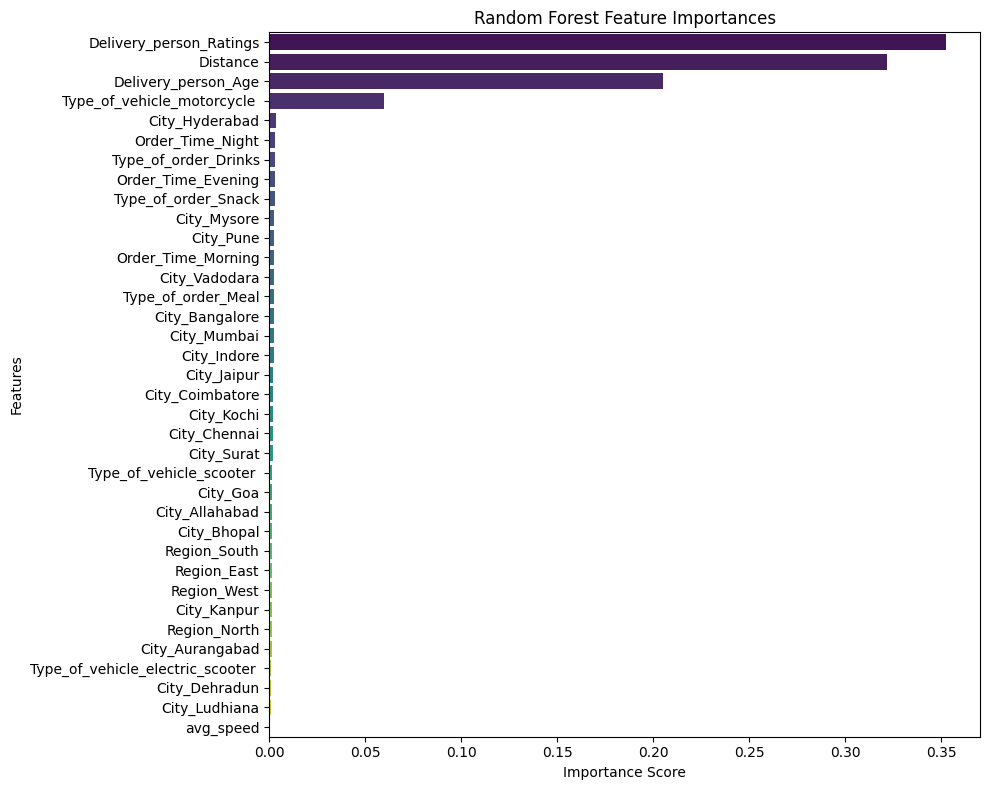

In [59]:
plt.figure(figsize=(10, 8))

# Plot
sns.barplot(
    x=features['coef_value'],
    y=features.index,
    palette='viridis'
)

# Titles and labels
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

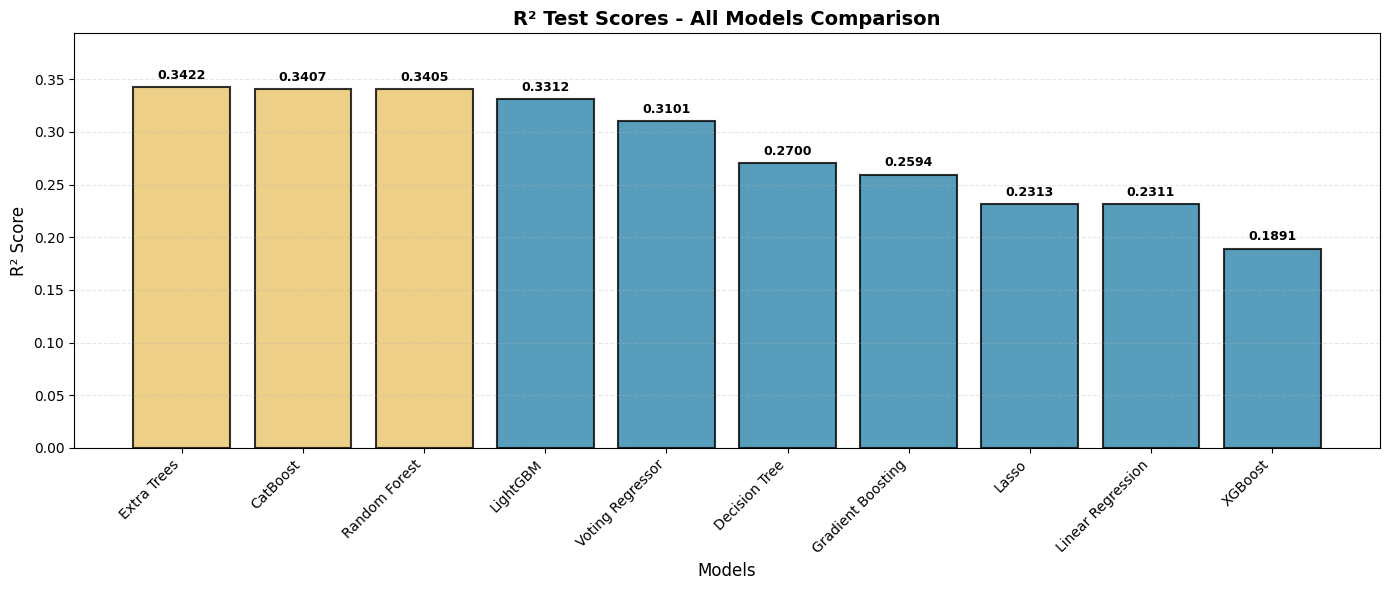

In [60]:
models_list = list(all_model_metrics.keys())
r2_test = [all_model_metrics[model]['R2_Test'] for model in models_list]
rmse_test = [all_model_metrics[model]['RMSE_Test'] for model in models_list]
mse_test = [all_model_metrics[model]['MSE_Test'] for model in models_list]

# 1. Bar Plot: R² Test Scores Only
plt.figure(figsize=(14, 6))

# Sort by R² score for better visualization
sorted_indices = np.argsort(r2_test)[::-1]
models_sorted = [models_list[i] for i in sorted_indices]
r2_sorted = [r2_test[i] for i in sorted_indices]

colors = ['#2E86AB'] * len(models_sorted)
for i in range(min(3, len(colors))):
    colors[i] = '#E9C46A'

bars = plt.bar(models_sorted, r2_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Test Scores - All Models Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.ylim(0, max(r2_sorted) * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

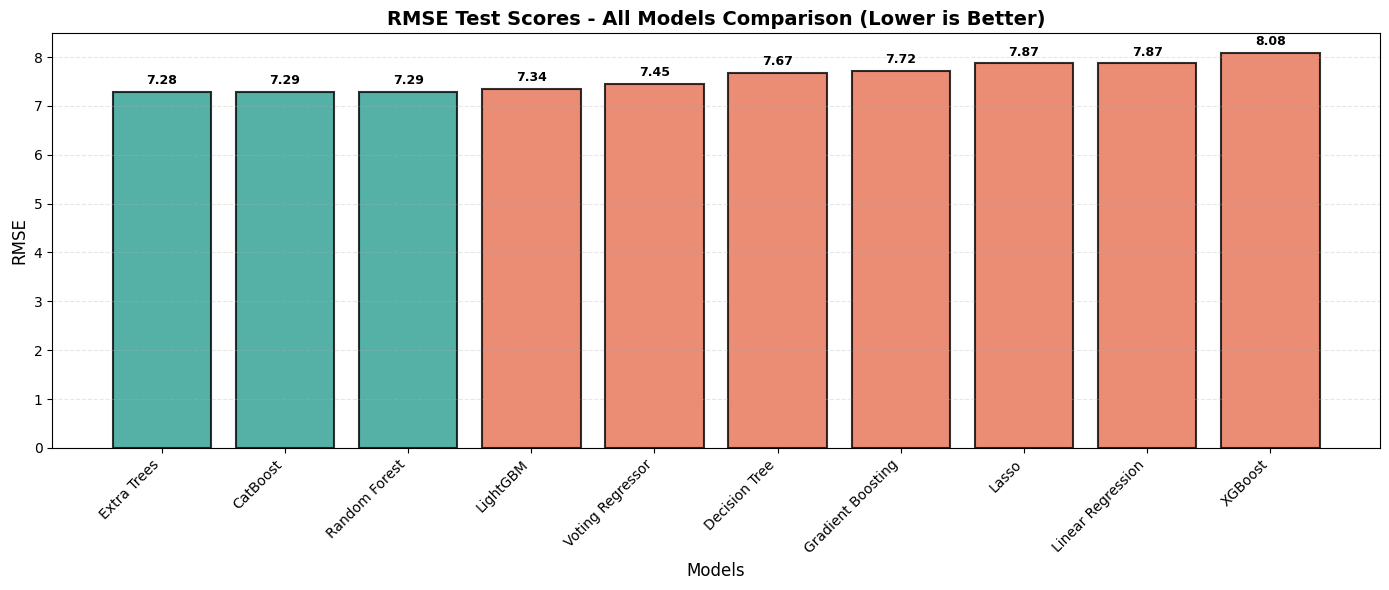

In [61]:
# 2. Bar Plot: RMSE Test Scores Only (Lower is Better)
plt.figure(figsize=(14, 6))

# Sort by RMSE score (ascending - lower is better)
sorted_indices = np.argsort(rmse_test)
models_sorted_rmse = [models_list[i] for i in sorted_indices]
rmse_sorted = [rmse_test[i] for i in sorted_indices]


colors = ['#E76F51'] * len(models_sorted_rmse)
for i in range(min(3, len(colors))):
    colors[i] = '#2A9D8F'

bars = plt.bar(models_sorted_rmse, rmse_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE Test Scores - All Models Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

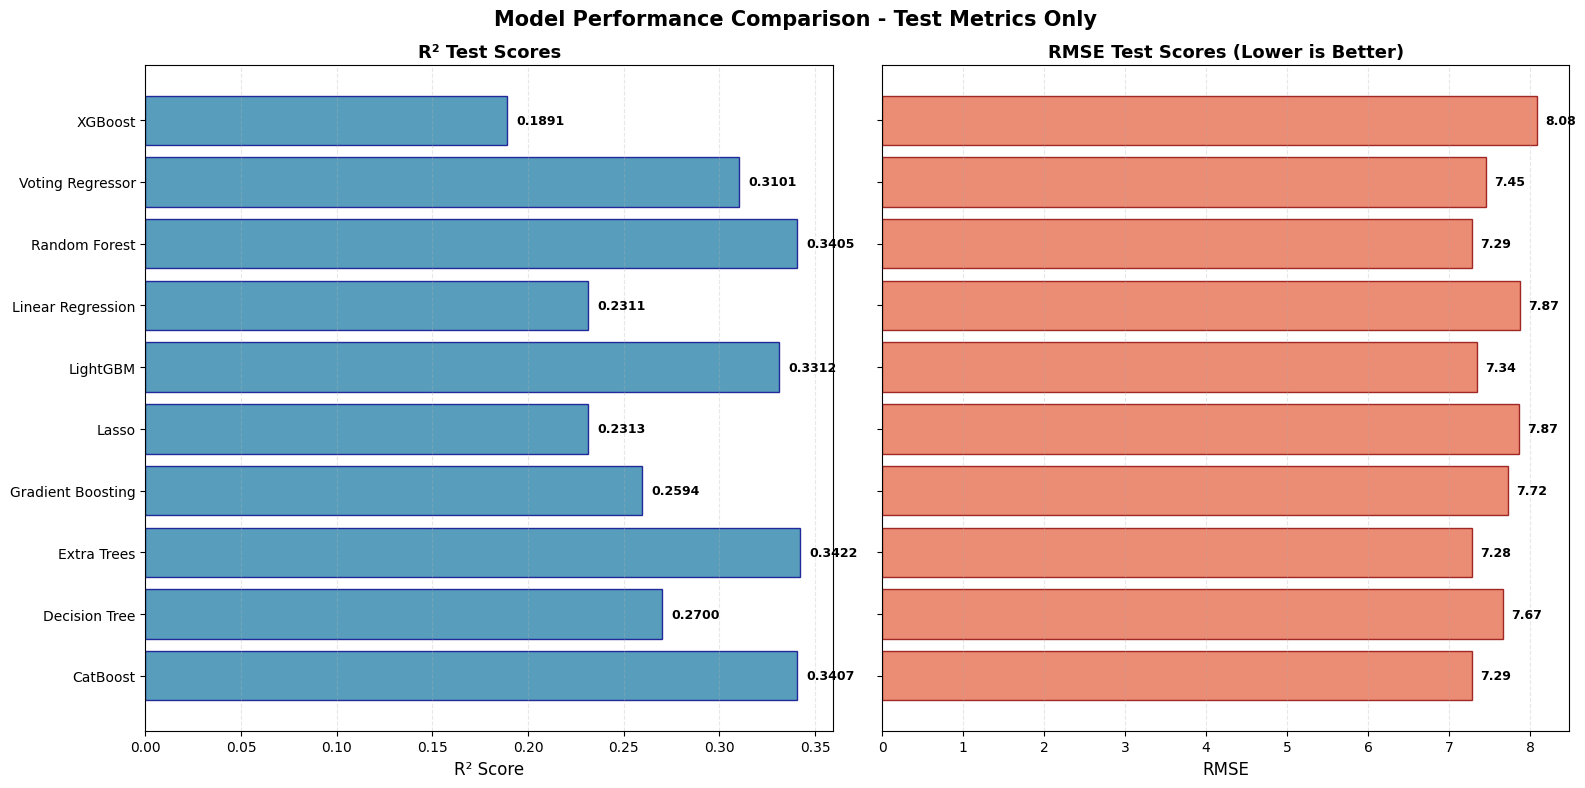

In [62]:
# 3. Combined Horizontal Bar Chart - R² and RMSE Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Sort models alphabetically for consistency
models_sorted_alpha = sorted(models_list)
r2_alpha = [all_model_metrics[model]['R2_Test'] for model in models_sorted_alpha]
rmse_alpha = [all_model_metrics[model]['RMSE_Test'] for model in models_sorted_alpha]

y_pos = np.arange(len(models_sorted_alpha))

bars1 = ax1.barh(y_pos, r2_alpha, color='#2E86AB', alpha=0.8, edgecolor='darkblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_sorted_alpha, fontsize=10)
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('R² Test Scores', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

bars2 = ax2.barh(y_pos, rmse_alpha, color='#E76F51', alpha=0.8, edgecolor='darkred')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xlabel('RMSE', fontsize=12)
ax2.set_title('RMSE Test Scores (Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison - Test Metrics Only', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()